# estimation prix jeux partie 2

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Notre historique de jeux vidéo
donnees_jeux = pd.DataFrame({
    'ventes_p1_millions': [1.2, 2.5, 0.5, 4.0, 1.8, 3.1, 0.2, 5.5, 2.2, 1.0, 3.8, 0.9, 2.9, 4.8, 1.5],
    'benefices_p2_millions_euros': [2.8, 5.2, 1.1, 8.9, 4.1, 6.5, 0.4, 11.8, 4.9, 2.1, 8.2, 1.9, 6.0, 10.2, 3.3]
})

# Regardons à quoi ressemble notre tableau
donnees_jeux

,ventes_p1_millions,benefices_p2_millions_euros
0,1.2,2.8
1,2.5,5.2
2,0.5,1.1
3,4.0,8.9
4,1.8,4.1
5,3.1,6.5
6,0.2,0.4
7,5.5,11.8
8,2.2,4.9
9,1.0,2.1


In [2]:
# X doit TOUJOURS être un tableau (un DataFrame), y est une simple liste (une Series)
X = donnees_jeux[['ventes_p1_millions']]
y = donnees_jeux['benefices_p2_millions_euros']

# On sépare (80% pour apprendre, 20% pour vérifier s'il est fort)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Création du modèle de régression
modele_jeux = LinearRegression()

# L'IA trace sa ligne magique en étudiant les données d'entraînement
modele_jeux.fit(X_train, y_train)
print("Moteur de régression entraîné avec succès !")

Moteur de régression entraîné avec succès !


In [4]:
# On prépare la donnée du nouveau jeu
nouveau_jeu = pd.DataFrame({'ventes_p1_millions': [2.0]})

# On demande la prédiction financière
prediction = modele_jeux.predict(nouveau_jeu)

print(f"Estimation :  {prediction[0]:.2f}")

Estimation :  4.32


In [5]:
print(f"Score de précision (R²) : {modele_jeux.score(X_test, y_test):.4f}")

Score de précision (R²) : 0.8924


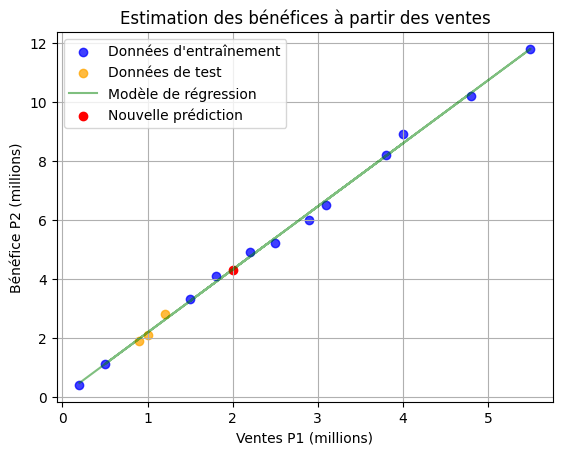

In [6]:
plt.scatter(X_train, y_train, color='blue', alpha=0.75, label='Données d\'entraînement')
plt.scatter(X_test, y_test, color='orange', alpha=0.75, label='Données de test')
plt.plot(X_train, modele_jeux.predict(X_train), color='green', alpha=0.5, label='Modèle de régression')
plt.scatter(nouveau_jeu, prediction, color='red', label='Nouvelle prédiction')
plt.title('Estimation des bénéfices à partir des ventes')
plt.xlabel('Ventes P1 (millions)')
plt.ylabel('Bénéfice P2 (millions)')
plt.grid(True)
plt.legend()
plt.show()

# estimation jeux partie 2 avec budget marketing

In [7]:
donnees_jeux_1 = donnees_jeux.copy()

In [8]:
# 1. On ajoute le budget marketing (en millions €)
donnees_jeux_1['budget_marketing'] = [0.5, 1.2, 0.1, 2.5, 0.8, 1.5, 0.05, 3.0, 1.1, 0.4, 2.0, 0.3, 1.4, 2.8, 0.7]

# 2. X contient maintenant DEUX colonnes
X = donnees_jeux_1[['ventes_p1_millions', 'budget_marketing']]
y = donnees_jeux_1['benefices_p2_millions_euros']

# 3. On entraîne
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X, y, test_size=0.2, random_state=42)
modele_jeux_1 = LinearRegression()
modele_jeux_1.fit(X_train_1, y_train_1)

LinearRegression()

In [9]:
print(f"Score de précision (R²) : {modele_jeux_1.score(X_test_1, y_test_1):.4f}")

Score de précision (R²) : 0.8889


In [10]:
# On prépare la donnée du nouveau jeu
nouveau_jeu_1 = pd.DataFrame({'ventes_p1_millions': [2.0],
                            'budget_marketing': [1.0]})

# On demande la prédiction financière
prediction_1 = modele_jeux_1.predict(nouveau_jeu_1)

print(f"Estimation :  {prediction[0]:.2f}")

Estimation :  4.32


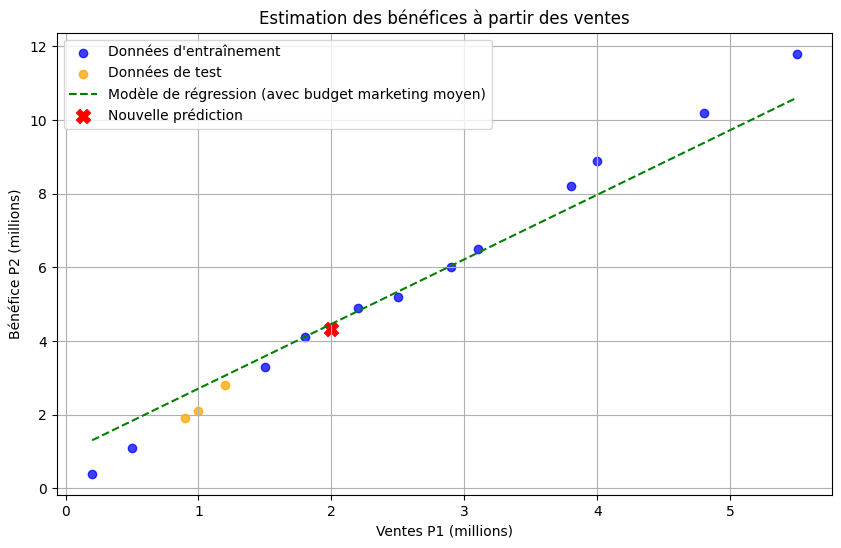

In [11]:
plt.figure(figsize=(10, 6))

# Nuage de points pour les données d'entraînement
plt.scatter(X_train_1['ventes_p1_millions'], y_train_1, color='blue', alpha=0.75, label='Données d\'entraînement')
# Nuage de points pour les données de test
plt.scatter(X_test_1['ventes_p1_millions'], y_test_1, color='orange', alpha=0.75, label='Données de test')

# Créer une plage de 'ventes_p1_millions' pour tracer la ligne de régression
x_min_plot = donnees_jeux_1['ventes_p1_millions'].min()
x_max_plot = donnees_jeux_1['ventes_p1_millions'].max()
x_range_for_plot = np.linspace(x_min_plot, x_max_plot, 100)

# Pour prédire avec un modèle à 2 caractéristiques, nous avons besoin de valeurs pour les deux caractéristiques.
# Utilisons la moyenne de 'budget_marketing' pour la deuxième caractéristique lors du traçage de la ligne.
mean_budget_marketing_for_plot = donnees_jeux_1['budget_marketing'].mean()
X_plot_line = pd.DataFrame({
    'ventes_p1_millions': x_range_for_plot,
    'budget_marketing': [mean_budget_marketing_for_plot] * len(x_range_for_plot)
})

# Prédire les 'benefices' pour cette plage
y_predicted_line = modele_jeux_1.predict(X_plot_line)

# Tracer la ligne de régression
plt.plot(X_plot_line['ventes_p1_millions'], y_predicted_line, color='green', linestyle='--', label='Modèle de régression (avec budget marketing moyen)')

# Tracer la nouvelle prédiction
plt.scatter(nouveau_jeu_1['ventes_p1_millions'], prediction_1, color='red', marker='X', s=100, label='Nouvelle prédiction')

plt.title('Estimation des bénéfices à partir des ventes')
plt.xlabel('Ventes P1 (millions)')
plt.ylabel('Bénéfice P2 (millions)')
plt.grid(True)
plt.legend()
plt.show()

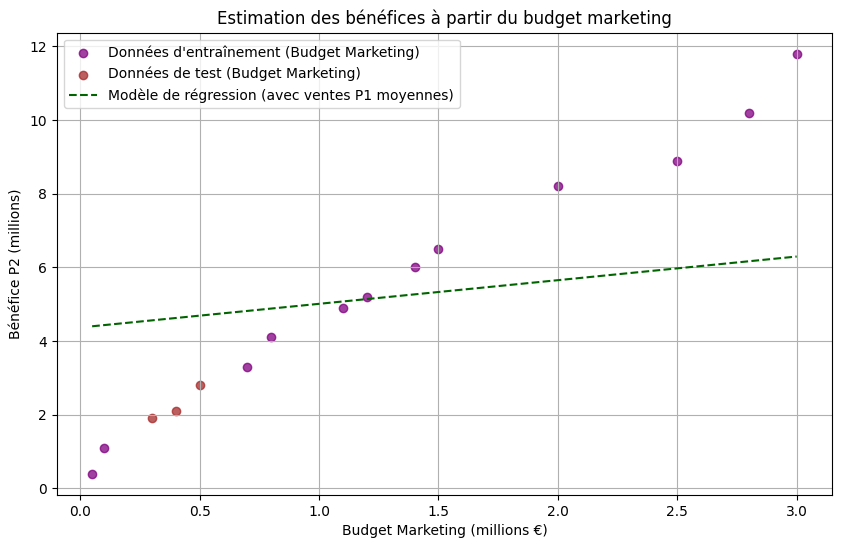

In [12]:
plt.figure(figsize=(10, 6))

# Nuage de points pour les données d'entraînement
plt.scatter(X_train_1['budget_marketing'], y_train_1, color='purple', alpha=0.75, label='Données d\'entraînement (Budget Marketing)')
# Nuage de points pour les données de test
plt.scatter(X_test_1['budget_marketing'], y_test_1, color='brown', alpha=0.75, label='Données de test (Budget Marketing)')

# Créer une plage de 'budget_marketing' pour tracer la ligne de régression
budget_min_plot = donnees_jeux_1['budget_marketing'].min()
budget_max_plot = donnees_jeux_1['budget_marketing'].max()
budget_range_for_plot = np.linspace(budget_min_plot, budget_max_plot, 100).reshape(-1, 1)

# Pour prédire avec un modèle à 2 caractéristiques, nous avons besoin de valeurs pour les deux caractéristiques.
# Utilisons la moyenne de 'ventes_p1_millions' pour la première caractéristique lors du traçage de la ligne.
mean_ventes_p1_for_plot = donnees_jeux_1['ventes_p1_millions'].mean()
X_plot_line_budget = pd.DataFrame({
    'ventes_p1_millions': [mean_ventes_p1_for_plot] * len(budget_range_for_plot),
    'budget_marketing': budget_range_for_plot.flatten()
})

# Prédire les 'benefices' pour cette plage
y_predicted_line_budget = modele_jeux_1.predict(X_plot_line_budget)

# Tracer la ligne de régression
plt.plot(X_plot_line_budget['budget_marketing'], y_predicted_line_budget, color='darkgreen', linestyle='--', label='Modèle de régression (avec ventes P1 moyennes)')

plt.title('Estimation des bénéfices à partir du budget marketing')
plt.xlabel('Budget Marketing (millions €)')
plt.ylabel('Bénéfice P2 (millions)')
plt.grid(True)
plt.legend()
plt.show()

# Clustering

In [13]:
from sklearn.cluster import KMeans

# 1. Données : [Temps de jeu par semaine, Argent dépensé]
X_joueurss = np.array([
    [1, 5], [1.5, 10], [2, 7],     # Groupe 1 : Joueurs occasionnels
    [20, 50], [25, 45], [22, 60],  # Groupe 2 : Passionnés
    [5, 200], [6, 180], [4, 250]   # Groupe 3 : Les "Baleines" (jouent peu mais paient beaucoup)
])

# 2. On demande à l'IA de trouver 3 groupes (n_clusters=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Ajout de n_init pour éviter le warning
clusters = kmeans.fit_predict(X_joueurss)

group = []

for x in clusters:
  if x == 2:
    group.append("Baleines")
  elif x == 1:
    group.append("Passionnés")
  else:
    group.append("Occasionnels")

print("Caractéristiques des joueurs et leurs groupes :\n")
for i in range(len(X_joueurss)):
  temps_de_jeu = X_joueurss[i, 0]
  argent_depense = X_joueurss[i, 1]
  categorie = group[i]
  print(f"Joueur {i+1}: Temps de jeu = {temps_de_jeu}h, Argent dépensé = {argent_depense}€ -> Catégorie: {categorie}")

Caractéristiques des joueurs et leurs groupes :

Joueur 1: Temps de jeu = 1.0h, Argent dépensé = 5.0€ -> Catégorie: Baleines
Joueur 2: Temps de jeu = 1.5h, Argent dépensé = 10.0€ -> Catégorie: Baleines
Joueur 3: Temps de jeu = 2.0h, Argent dépensé = 7.0€ -> Catégorie: Baleines
Joueur 4: Temps de jeu = 20.0h, Argent dépensé = 50.0€ -> Catégorie: Occasionnels
Joueur 5: Temps de jeu = 25.0h, Argent dépensé = 45.0€ -> Catégorie: Occasionnels
Joueur 6: Temps de jeu = 22.0h, Argent dépensé = 60.0€ -> Catégorie: Occasionnels
Joueur 7: Temps de jeu = 5.0h, Argent dépensé = 200.0€ -> Catégorie: Passionnés
Joueur 8: Temps de jeu = 6.0h, Argent dépensé = 180.0€ -> Catégorie: Passionnés
Joueur 9: Temps de jeu = 4.0h, Argent dépensé = 250.0€ -> Catégorie: Passionnés


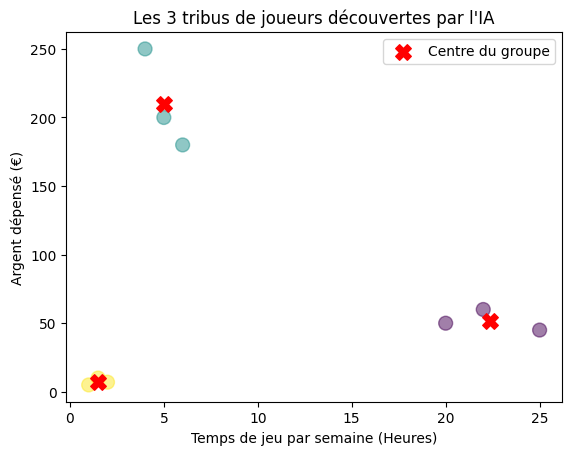

In [14]:
# --- CODE POUR LE GRAPHIQUE DU CLUSTERING ---
# On sépare les données pour le graphique : Temps (axe X) et Argent (axe Y)
plt.scatter(X_joueurss[:, 0], X_joueurss[:, 1], c=clusters, alpha=0.5, cmap='viridis', s=100)

# On affiche les "Centroïdes" (le joueur typique/le centre de chaque groupe trouvé par l'IA)
centres = kmeans.cluster_centers_
plt.scatter(centres[:, 0], centres[:, 1], color='red', marker='X', s=125, label='Centre du groupe')

plt.xlabel('Temps de jeu par semaine (Heures)')
plt.ylabel('Argent dépensé (€)')
plt.title('Les 3 tribus de joueurs découvertes par l\'IA')
plt.legend()
plt.show()

In [15]:
# 1. Données de 9 joueurs : [Temps de jeu par semaine (heures), Argent dépensé par mois (€)]
X_joueurs = np.array([
    [1, 5], [2, 8], [1.5, 4],       # Groupe A : Joueurs occasionnels
    [25, 45], [30, 10], [22, 50],   # Groupe B : Les passionnés
    [4, 200], [5, 350], [3, 180]# Groupe C : Les "Baleines" (jouent peu, dépensent énormément)
])

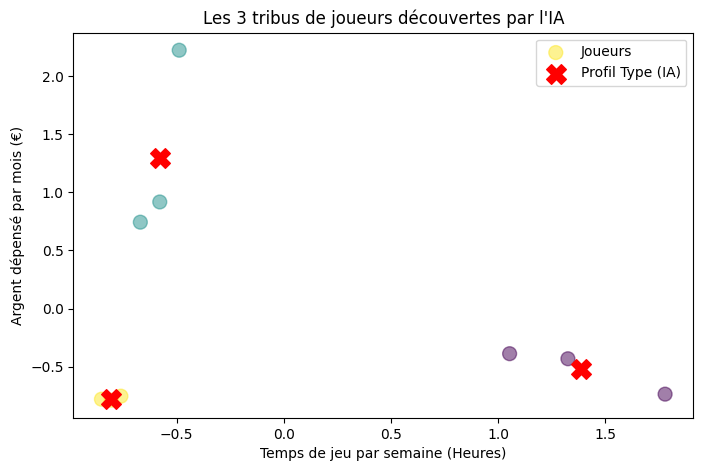

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Correction: Instancier le StandardScaler et transformer les données si l'intention est de les scaler.
scaler = StandardScaler()
X_joueurs_scaled = scaler.fit_transform(X_joueurs)
# Si la ligne ci-dessus n'est pas nécessaire, elle peut être supprimée.

# 2. On demande à K-Means de trouver les 3 tribus cachées
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Ajout de n_init pour éviter le warning
predictions_groupes = kmeans.fit_predict(X_joueurs_scaled)

# 3. On dessine le graphique pour voir les groupes
plt.figure(figsize=(8, 5))
# L'IA colorie chaque point selon le groupe qu'elle a elle-même créé
plt.scatter(X_joueurs_scaled[:, 0], X_joueurs_scaled[:, 1], c=predictions_groupes, cmap='viridis', s=100, alpha=0.5, label='Joueurs')

# On affiche les "Centres" (le joueur typique de chaque tribu calculé par l'IA)
centres = kmeans.cluster_centers_
plt.scatter(centres[:, 0], centres[:, 1], color='red', marker='X', s=200, label='Profil Type (IA)')

plt.xlabel('Temps de jeu par semaine (Heures)')
plt.ylabel('Argent dépensé par mois (€)')
plt.title('Les 3 tribus de joueurs découvertes par l\'IA')
plt.legend()
plt.show()

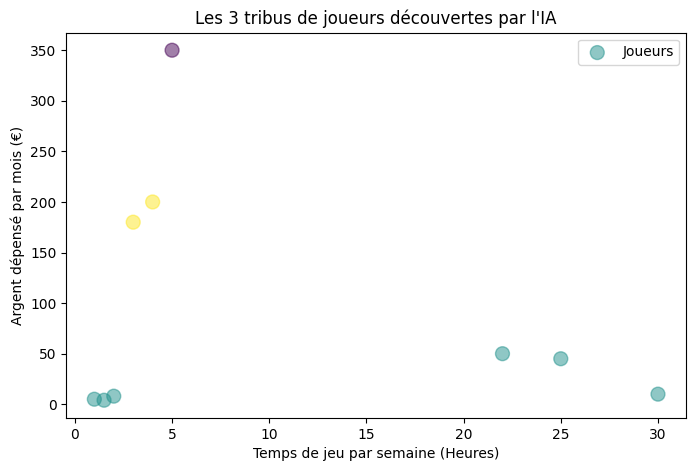

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Correction: Instancier le StandardScaler et transformer les données si l'intention est de les scaler.
scaler = StandardScaler()
X_joueurs_scaled = scaler.fit_transform(X_joueurs)
# Si la ligne ci-dessus n'est pas nécessaire, elle peut être supprimée.

# 2. On demande à K-Means de trouver les 3 tribus cachées
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # Ajout de n_init pour éviter le warning
predictions_groupes = kmeans.fit_predict(X_joueurs)

# 3. On dessine le graphique pour voir les groupes
plt.figure(figsize=(8, 5))
# L'IA colorie chaque point selon le groupe qu'elle a elle-même créé
plt.scatter(X_joueurs[:, 0], X_joueurs[:, 1], c=predictions_groupes
            , cmap='viridis', s=100, alpha=0.5, label='Joueurs')

# On affiche les "Centres" (le joueur typique de chaque tribu calculé par l'IA)
centres = kmeans.cluster_centers_
# plt.scatter(centres[:, 0], centres[:, 1], color='red', marker='X', s=100, label='Profil Type (IA)')

plt.xlabel('Temps de jeu par semaine (Heures)')
plt.ylabel('Argent dépensé par mois (€)')
plt.title('Les 3 tribus de joueurs découvertes par l\'IA')
plt.legend()
plt.show()

## Clustering avec des centaines de données simulées

Pour démontrer le clustering avec un plus grand ensemble de données, nous allons générer artificiellement des centaines de points représentant des joueurs, divisés en trois catégories distinctes : les joueurs occasionnels, les passionnés et les 'baleines'.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Paramètres pour la génération des données
np.random.seed(42)
n_samples = 300 # Nombre total de joueurs

# Groupe 1: Joueurs Occasionnels (peu de temps de jeu, peu d'argent dépensé)
occasionnels_time = np.random.normal(loc=3, scale=1.5, size=(n_samples // 3, 1))
occasionnels_money = np.random.normal(loc=10, scale=5, size=(n_samples // 3, 1))
group_occasionnels = np.hstack((occasionnels_time, occasionnels_money))

# Groupe 2: Passionnés (beaucoup de temps de jeu, argent dépensé modéré)
passionnes_time = np.random.normal(loc=25, scale=5, size=(n_samples // 3, 1))
passionnes_money = np.random.normal(loc=70, scale=20, size=(n_samples // 3, 1))
group_passionnes = np.hstack((passionnes_time, passionnes_money))

# Groupe 3: Baleines (temps de jeu modéré, beaucoup d'argent dépensé)
baleines_time = np.random.normal(loc=8, scale=3, size=(n_samples // 3, 1))
baleines_money = np.random.normal(loc=300, scale=70, size=(n_samples // 3, 1))
group_baleines = np.hstack((baleines_time, baleines_money))

# Combinaison des groupes pour former le dataset complet
X_joueurs_large = np.vstack((group_occasionnels, group_passionnes, group_baleines))

# Assurons-nous que les valeurs sont positives
X_joueurs_large[X_joueurs_large < 0] = 0

print("Aperçu des premières données générées (Temps de jeu, Argent dépensé) :")
print(X_joueurs_large[:5])
print("...")
print(f"Total de {len(X_joueurs_large)} joueurs générés.")

Aperçu des premières données générées (Temps de jeu, Argent dépensé) :
[[3.74507123 2.92314629]
 [2.79260355 7.89677339]
 [3.97153281 8.28642742]
 [5.28454478 5.98861365]
 [2.64876994 9.19357144]]
...
Total de 300 joueurs générés.


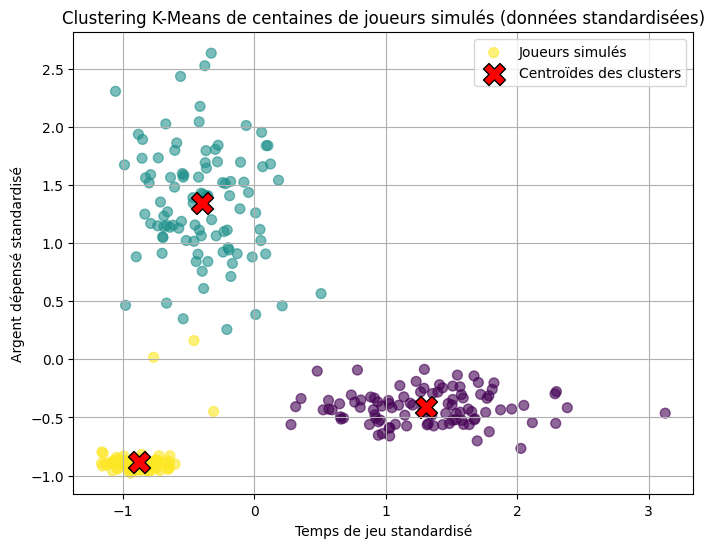

In [27]:
# 1. Standardisation des données (important pour KMeans quand les échelles sont différentes)
scaler_large = StandardScaler()
X_joueurs_large_scaled = scaler_large.fit_transform(X_joueurs_large)

# 2. Application de K-Means pour trouver 3 groupes
kmeans_large = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_large = kmeans_large.fit_predict(X_joueurs_large_scaled)

# 3. Visualisation des clusters
plt.figure(figsize=(8, 6))
plt.scatter(X_joueurs_large_scaled[:, 0], X_joueurs_large_scaled[:, 1], c=clusters_large, cmap='viridis', s=50, alpha=0.6, label='Joueurs simulés')

# Affichage des centroïdes
centres_large = kmeans_large.cluster_centers_
plt.scatter(centres_large[:, 0], centres_large[:, 1], color='red', marker='X', s=250, label='Centroïdes des clusters', edgecolor='black')

plt.title('Clustering K-Means de centaines de joueurs simulés (données standardisées)')
plt.xlabel('Temps de jeu standardisé')
plt.ylabel('Argent dépensé standardisé')
plt.legend()
plt.grid(True)
plt.show()

Ce graphique montre comment l'algorithme K-Means a réussi à identifier trois groupes distincts au sein de nos centaines de joueurs simulés, même si les données sont devenues plus denses. Les croix rouges représentent les 'joueurs typiques' ou centroïdes de chaque groupe.